# IMPORTING DATASETS & PACKAGES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [5]:
crops_df=pd.read_csv("../Crop_recommendation.csv")

In [9]:
crops_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [380]:
# Map encoded labels back to crop names
for i, crop in enumerate(le.classes_):
    print(f"{i} -> {crop}")

0 -> apple
1 -> banana
2 -> blackgram
3 -> chickpea
4 -> coconut
5 -> coffee
6 -> cotton
7 -> grapes
8 -> jute
9 -> kidneybeans
10 -> lentil
11 -> maize
12 -> mango
13 -> mothbeans
14 -> mungbean
15 -> muskmelon
16 -> orange
17 -> papaya
18 -> pigeonpeas
19 -> pomegranate
20 -> rice
21 -> watermelon


# DATA PREPROCESSING

In [12]:
crops_df=crops_df.rename(columns={'label':'crops'})

# LABEL ENCODING

In [168]:
from sklearn.preprocessing import LabelEncoder

In [132]:
le=LabelEncoder()

In [134]:
y = le.fit_transform(crops_df["crops"])

# Model Training

**model 1 (without any evaluation)**

In [327]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [329]:
decisionTree=DecisionTreeClassifier(random_state=42)

In [331]:
X=crops_df.drop(columns="crops")

In [333]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [335]:
model=decisionTree.fit(X_train,Y_train)

In [337]:
model

DecisionTreeClassifier(random_state=42)

In [339]:
acc = model.score(X_test, y_test)
print("Accuracy:", acc)

Accuracy: 0.9795454545454545


In [341]:
train_score = model.score(X_train, Y_train)
print("Training Accuracy:", train_score)

Training Accuracy: 1.0


In [343]:
Y_pred = model.predict(X_test)

In [345]:
test_score = accuracy_score(Y_test, Y_pred)
print("Test Accuracy:", test_score)

Test Accuracy: 0.9795454545454545


**Visualizing model 1 of decision Tree**

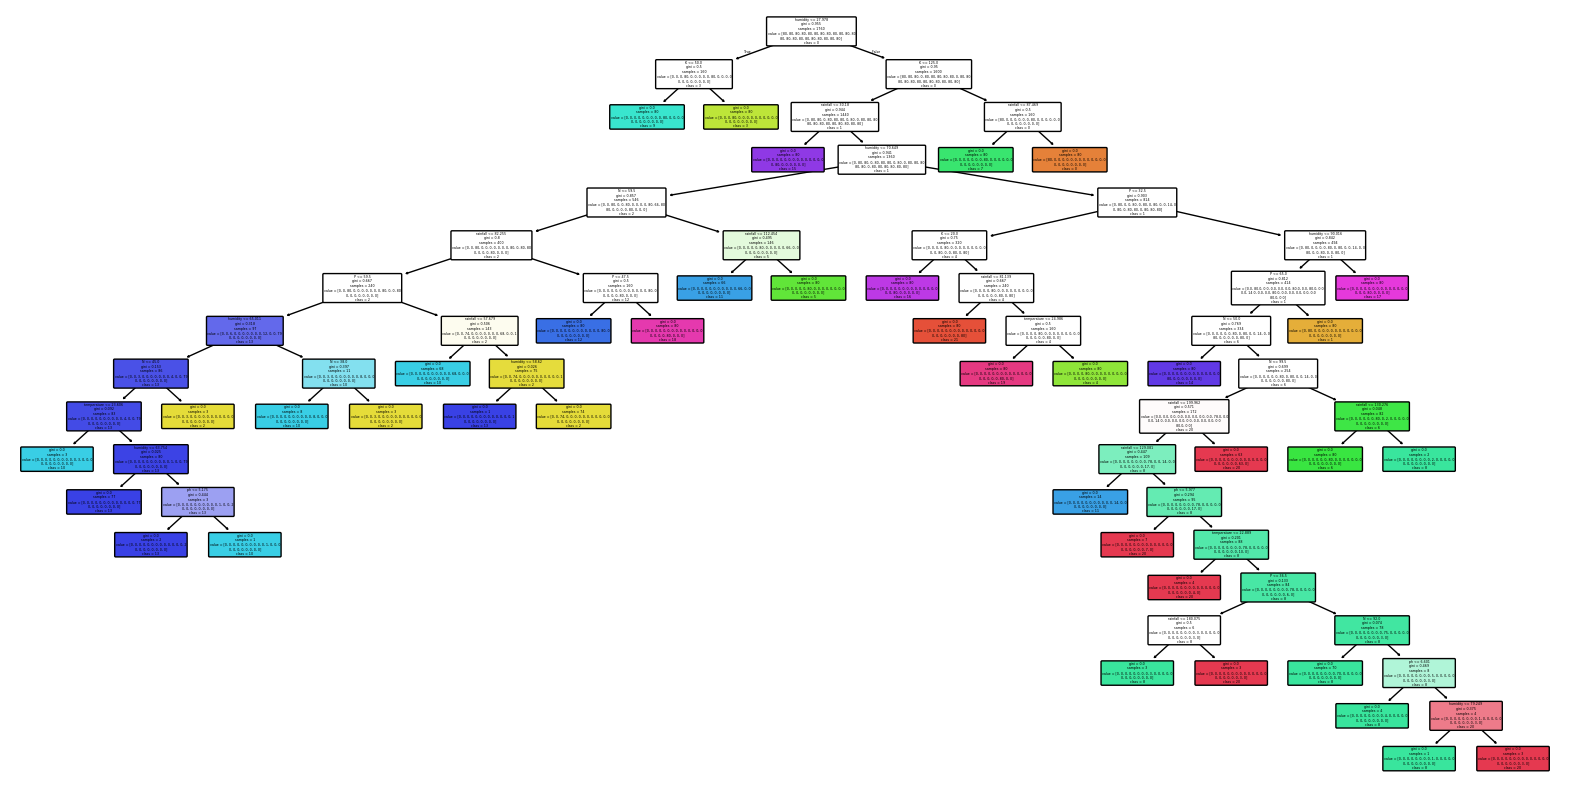

In [305]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(
    decisionTree,
    feature_names=X.columns,
    class_names=[str(cls) for cls in sorted(set(y))],
    filled=True,
    rounded=True
)
plt.show()


**model 2(using GridSearchCV)**

In [348]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train, Y_train)

print("Best Params:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Accuracy: 0.9875


In [350]:
decisionTree=DecisionTreeClassifier(random_state=0,max_depth=None,min_samples_split=2,min_samples_leaf=1)

In [352]:
model=decisionTree.fit(X_train,Y_train)

In [354]:
model

DecisionTreeClassifier(random_state=0)

In [356]:
acc = model.score(X_test, Y_test)
print("Accuracy:", acc)

Accuracy: 0.9795454545454545


In [358]:
train_score = model.score(X_train, Y_train)
print("Training Accuracy:", train_score)

Training Accuracy: 1.0


In [360]:
Y_pred=model.predict(X_test)

In [362]:
test_score = accuracy_score(Y_test, Y_pred)
print("Test Accuracy:", test_score)

Test Accuracy: 0.9795454545454545


# Model Export

In [367]:
import joblib

In [369]:
joblib.dump(model,'crop_recommendation_model_dt.pkl')

['crop_recommendation_model_dt.pkl']

In [371]:
best_params = grid.best_params_
joblib.dump(best_params, 'best_params_dt.pkl')

['best_params_dt.pkl']

In [376]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']

In [384]:
model.predict([[80, 50, 50, 30.0, 60.0, 6.8, 100.0]])

C:\Users\vasug\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([11])